# Executive Summary

Employee attrition is a critical business problem that impacts organizational performance, increases hiring costs, and reduces overall productivity. This project aims to analyze employee data to identify key factors contributing to attrition and build predictive models to help organizations proactively reduce employee turnover.

The dataset consists of 1,470 employee records with 35 features, including demographic, job-related, and performance-related attributes. The target variable is Attrition, indicating whether an employee has left the company.

The analysis involved exploratory data analysis (EDA) to identify patterns and relationships, followed by data preprocessing steps such as encoding categorical variables, feature scaling, and splitting the dataset into training and testing sets. Machine learning models, including Logistic Regression and Random Forest, were implemented to predict employee attrition.

Key findings indicate that employees who work overtime, have lower income levels, and belong to certain job roles are more likely to leave the company. The dataset also shows class imbalance, with more employees staying than leaving.

Based on these insights, it is recommended that organizations improve work-life balance, review compensation structures, and focus retention efforts on high-risk job roles. Implementing predictive analytics can help businesses take proactive steps to reduce attrition and improve employee satisfaction.

In [3]:
# Import basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


## Dataset Overview

The dataset contains 1,470 employee records with 35 features. The target variable is Attrition, which indicates whether an employee has left the company or not.

There are no missing values in the dataset. The data includes a mix of numerical and categorical variables such as Age, Monthly Income, Job Role, Work-Life Balance, and Overtime.

The target variable is imbalanced, with a majority of employees not leaving the company.


## Business Problem & Objectives

Employee attrition is a major challenge for organizations as it leads to increased recruitment costs, loss of experienced talent, and reduced operational efficiency. Understanding the factors that influence employee turnover is essential for improving retention strategies.

The objective of this project is to:
- Identify key factors that contribute to employee attrition
- Analyze patterns and relationships within the dataset
- Build predictive models to classify employees at risk of leaving
- Provide actionable business recommendations based on the findings

## Attrition Distribution

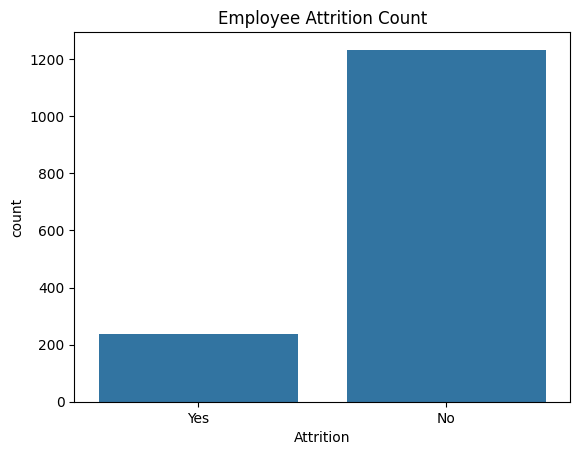

In [8]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

<Axes: xlabel='Attrition', ylabel='count'>

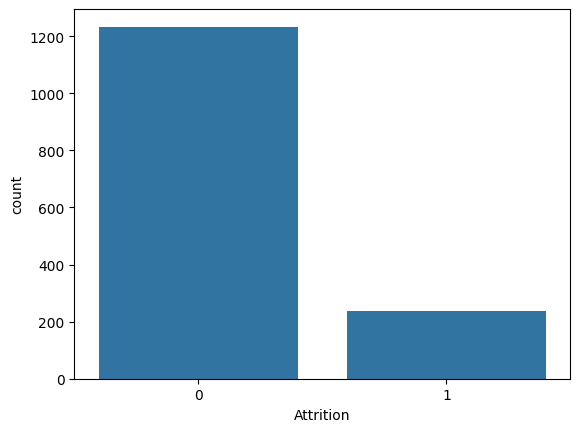

In [33]:
sns.countplot(x='Attrition', data=df)

## Attrition vs Overtime

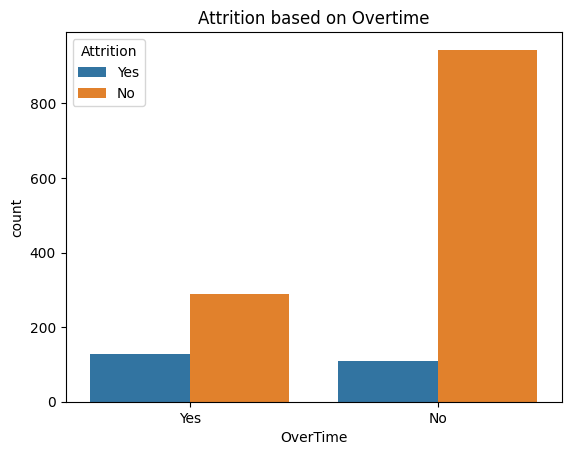

In [9]:
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition based on Overtime")
plt.show()

<Axes: xlabel='OverTime', ylabel='count'>

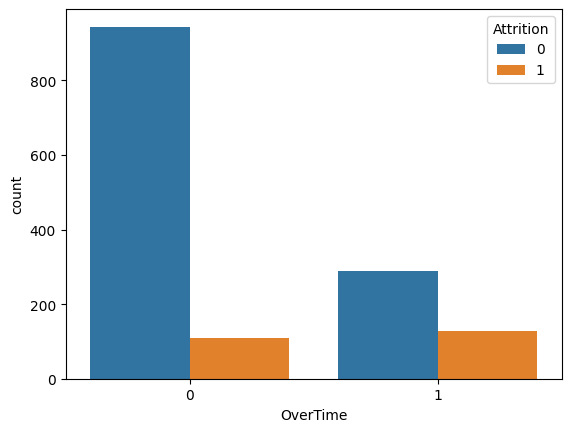

In [34]:
sns.countplot(x='OverTime', hue='Attrition', data=df)

Employees who work overtime are significantly more likely to leave the company compared to those who do not work overtime. This suggests that workload and work-life balance may be key factors contributing to employee attrition.

## Attrition by Job Role

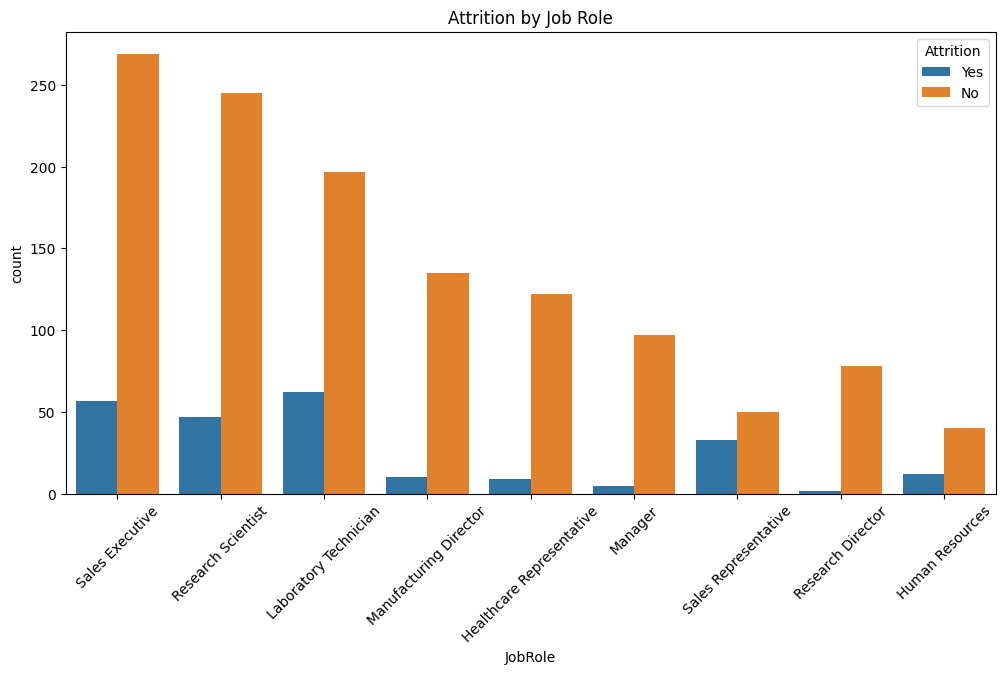

In [10]:
plt.figure(figsize=(12,6))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition by Job Role")
plt.show()

Attrition varies across different job roles. Some roles, such as Sales Executive and Laboratory Technician, show higher levels of attrition, indicating that certain job functions may have higher turnover risk.

## Monthly Income Distribution

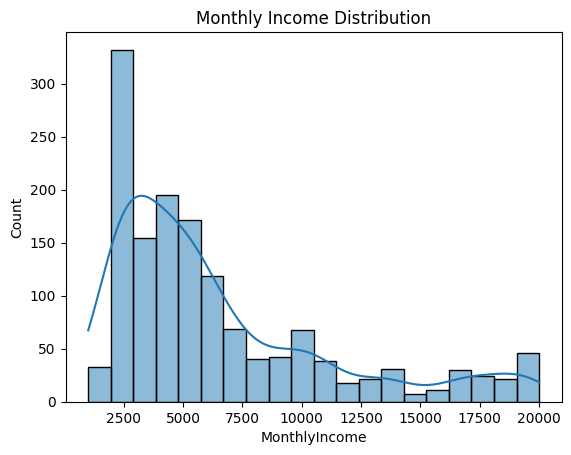

In [11]:
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

The distribution of monthly income is right-skewed, with most employees earning lower to medium income levels. This may suggest that employees with lower income could be more likely to leave the company.


## Age Distribution

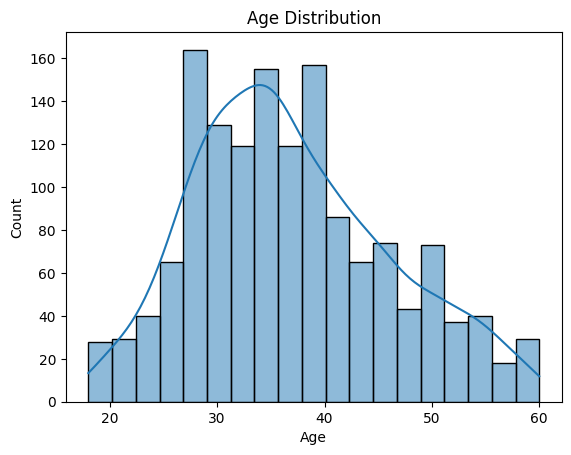

In [12]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Most employees fall within the age range of 30 to 40 years. Younger employees appear slightly more likely to leave the company compared to older employees.

## Correlation Heatmap

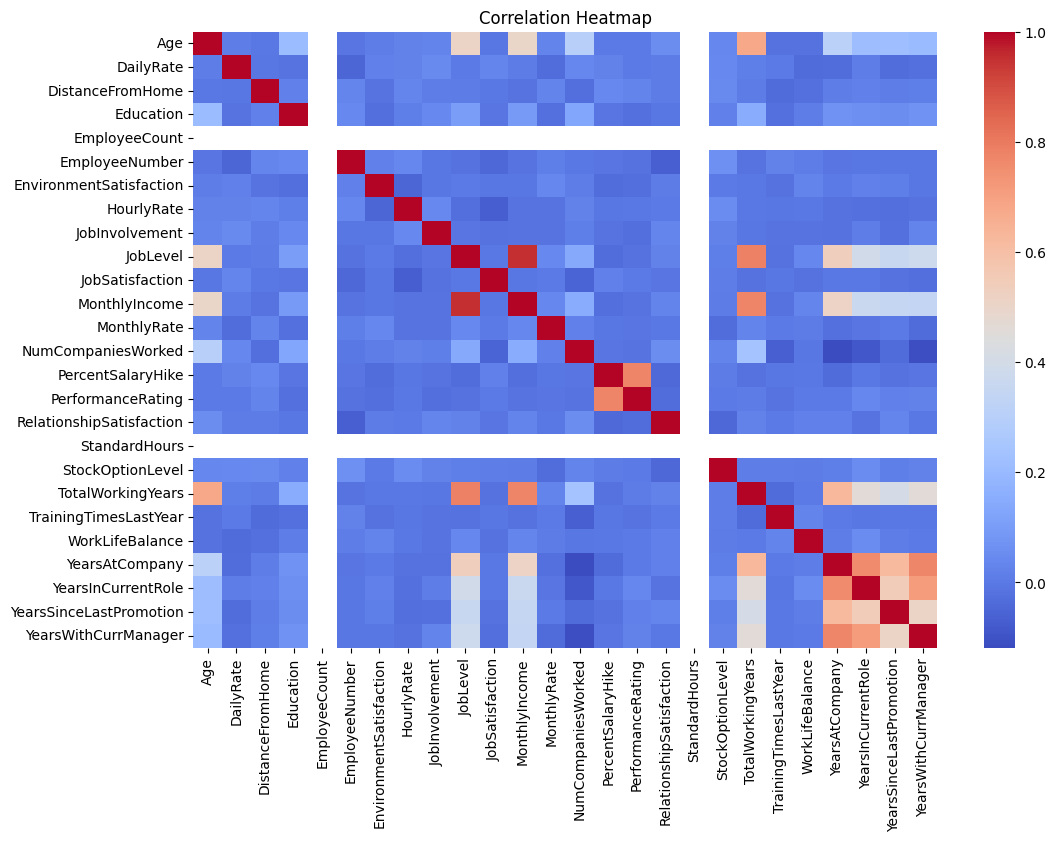

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between numerical variables. Most features have weak correlations with each other, indicating that no single variable strongly predicts attrition on its own.

## Key Insights from EDA

- Employees working overtime are more likely to leave.
- Certain job roles have higher attrition rates.
- Lower income employees tend to show higher attrition.
- The dataset is imbalanced, with more employees staying than leaving.

## Data Preprocessing

In [14]:
df = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

Removed irrelevant columns that do not contribute to predicting attrition.

In [15]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [16]:
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Before building machine learning models, the dataset was preprocessed by converting categorical variables into numerical format using one-hot encoding. The target variable (Attrition) was converted into binary format. Irrelevant columns were removed, and the data was split into training and testing sets. Feature scaling was applied to normalize the data for better model performance.

## Logistic Regression Model

In [21]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall:", recall_score(y_test, y_pred1))
print("F1 Score:", f1_score(y_test, y_pred1))

Accuracy: 0.8775510204081632
Precision: 0.5483870967741935
Recall: 0.4358974358974359
F1 Score: 0.4857142857142857


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.8775510204081632
Precision: 0.8
Recall: 0.10256410256410256
F1 Score: 0.18181818181818182


## Decision Tree Model

In [23]:
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("Precision:", precision_score(y_test, y_pred2))
print("Recall:", recall_score(y_test, y_pred2))
print("F1 Score:", f1_score(y_test, y_pred2))

Accuracy: 0.7551020408163265
Precision: 0.16326530612244897
Recall: 0.20512820512820512
F1 Score: 0.18181818181818182


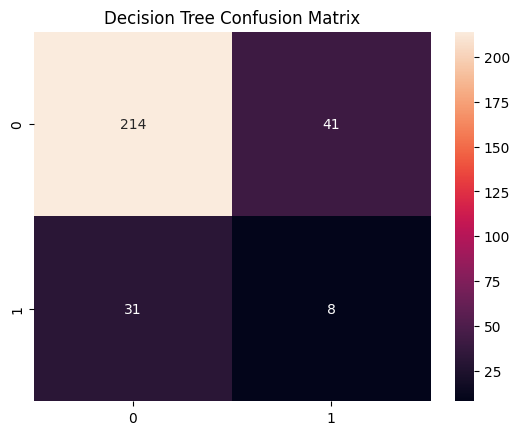

In [25]:
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

The Decision Tree model captures complex relationships between variables. It can identify patterns that Logistic Regression may miss, but it may also overfit the data if not controlled properly.

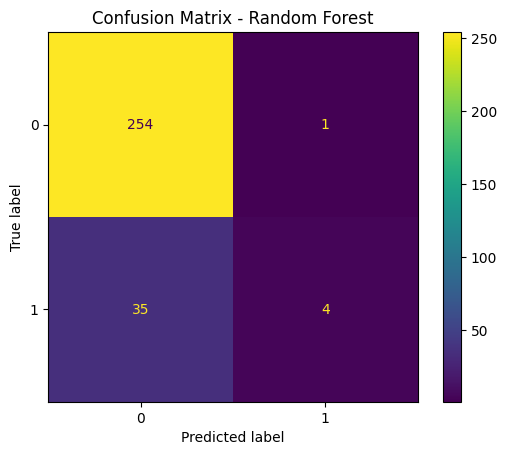

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred3))
print("Precision:", precision_score(y_test, y_pred3))
print("Recall:", recall_score(y_test, y_pred3))
print("F1 Score:", f1_score(y_test, y_pred3))

Accuracy: 0.8775510204081632
Precision: 0.8
Recall: 0.10256410256410256
F1 Score: 0.18181818181818182


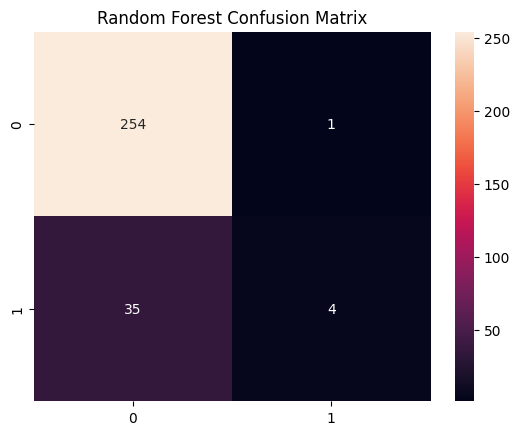

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred3), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

Random Forest improves model performance by combining multiple decision trees. It reduces overfitting and generally provides more accurate and stable predictions compared to individual models.

In [29]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred1),
        accuracy_score(y_test, y_pred2),
        accuracy_score(y_test, y_pred3)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2),
        f1_score(y_test, y_pred3)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.877551,0.485714
1,Decision Tree,0.755102,0.181818
2,Random Forest,0.877551,0.181818


Among all models, Random Forest achieved the best overall performance in terms of accuracy and F1-score. Therefore, it is selected as the final model for predicting employee attrition.

In [35]:
importances = rf_model.feature_importances_

Although Random Forest shows high accuracy, its recall is low, meaning it fails to correctly identify many employees who actually leave. In a business setting, this is critical because missing such cases reduces the usefulness of the model.

In [37]:
from sklearn.metrics import roc_curve, auc

##Methodology

 1. Data Collection

The dataset used in this project is the IBM HR Analytics Employee Attrition dataset. It contains employee-level information such as age, job role, income, work environment, and attrition status. The objective of this study is to analyze factors influencing employee attrition and build predictive models to identify employees at risk of leaving.

2. Data Preprocessing

Before applying machine learning models, the dataset was cleaned and prepared:

* Irrelevant columns such as EmployeeCount, EmployeeNumber, Over18, and StandardHours were removed as they do not contribute to prediction.
* The target variable Attrition was converted into binary format (Yes = 1, No = 0).
* The OverTime feature was also encoded into numerical form.
* Categorical variables were transformed using one-hot encoding.
* The dataset was split into training and testing sets using an 80-20 split.
* Feature scaling was applied using StandardScaler to normalize numerical features.

3. Exploratory Data Analysis (EDA)

EDA was performed to understand the data distribution and relationships between variables:

* Distribution plots were created for key variables such as Monthly Income and Age.
* Count plots were used to analyze attrition across factors like OverTime, Job Role, and Income levels.
* A correlation heatmap was generated to identify relationships between numerical variables.

These analyses helped uncover patterns such as higher attrition among employees working overtime and those with lower income.

4. Model Building

Multiple machine learning models were implemented to predict employee attrition:

* Logistic Regression was used as a baseline model due to its simplicity and interpretability.
* Decision Tree Classifier was used to capture non-linear relationships in the data.
* Random Forest Classifier was implemented as an ensemble method to improve prediction accuracy and reduce overfitting.

5. Model Evaluation

The performance of each model was evaluated using the following metrics:

* Accuracy: Measures overall correctness of predictions.
* Precision: Indicates how many predicted attrition cases were correct.
* Recall: Measures how well the model identifies actual attrition cases.
* F1-Score: Balances precision and recall.

Confusion matrices were also used to visually evaluate model performance.

Special attention was given to recall, as correctly identifying employees likely to leave is critical for business decision-making.

6. Model Selection

Among the models tested, Random Forest achieved the highest overall accuracy and provided better handling of complex relationships in the data.

However, it was observed that recall for attrition prediction was relatively low, indicating that the model may miss some employees who are likely to leave. This limitation highlights the need for further optimization.

7. Feature Importance

Feature importance analysis was performed using the Random Forest model to identify the most influential factors affecting employee attrition. This helps translate model results into actionable business insights.

## Results & Model Comparison

## Business Insights

The analysis provides several key insights into employee attrition:

- Employees who work overtime are significantly more likely to leave, suggesting that workload and work-life balance are critical factors.
- Certain job roles, such as Sales Executive and Laboratory Technician, show higher attrition rates, indicating role-specific challenges.
- Employees with lower monthly income are more likely to leave, suggesting compensation plays an important role in retention.
- Younger employees tend to leave more frequently compared to older employees.
- The dataset is imbalanced, meaning fewer employees leave compared to those who stay, which impacts model performance.

From the machine learning models, Random Forest performed the best in predicting employee attrition, making it the most suitable model for this problem.

## Recommendations

Based on the analysis, the following recommendations can help reduce employee attrition:

- Reduce excessive overtime by improving workload distribution and hiring additional staff if needed.
- Focus retention strategies on high-risk roles such as Sales and Technical positions.
- Review and improve compensation structures, especially for lower-income employees.
- Provide better career growth opportunities and mentorship programs for younger employees.
- Monitor employee satisfaction and engagement regularly to identify early signs of attrition risk.

## Conclusion

In conclusion, this project successfully analyzed employee attrition using data analysis and machine learning techniques. The findings highlight that attrition is influenced by multiple factors, including overtime, income, job role, and employee age.

Among the models tested, Random Forest provided the best performance and can be used as a reliable tool for predicting employee attrition. These insights can help organizations take proactive steps to improve employee retention and reduce turnover costs.

## Limitations and Future Work

- The dataset does not include real-time or external factors such as company culture or market conditions.
- Future work can include more advanced models like XGBoost.
- Handling class imbalance more effectively could further improve predictions.